In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score



In [4]:

df = pd.read_csv(r"C:\Users\QAYAD ALI\qayad-project\disaster.csv", encoding="latin-1")

print("Raw dataset shape:", df.shape)
print("\nColumn names:")
for col in df.columns:
    print(" ", col)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\QAYAD ALI\\qayad-project\\disaster.csv'

In [3]:
relevant_types = ["Flood", "Storm", "Earthquake", "Wildfire"]

impact_df = df[df["Disaster Type"].isin(relevant_types)].copy()

print("Rows after filtering:", len(impact_df))
print()
print(impact_df["Disaster Type"].value_counts())

Rows after filtering: 10866

Disaster Type
Flood         5272
Storm         4005
Earthquake    1137
Wildfire       452
Name: count, dtype: int64


In [4]:
impact_df = impact_df[[
    "Disaster Type",                       
    "Start Year",                        
    "Region",                             
    "Dis Mag Value",                       
    "Total Affected",                      
    "Total Damages ('000 US$)"    
]].copy()


impact_df.rename(columns={
    "Dis Mag Value":"Magnitude",
    "Total Damages ('000 US$)": "Economic_Damage"
}, inplace=True)

print("Selected columns shape:", impact_df.shape)
print()
print(impact_df.head())

Selected columns shape: (10866, 6)

  Disaster Type  Start Year                     Region  Magnitude  \
0         Flood        1970              South America        NaN   
1         Storm        1970  Australia and New Zealand        NaN   
2         Flood        1970             Western Africa        NaN   
3         Storm        1970              Southern Asia        NaN   
4         Storm        1970              Southern Asia        NaN   

   Total Affected  Economic_Damage  
0             NaN          25000.0  
1             NaN          72475.0  
2             NaN            200.0  
3       3648000.0          86400.0  
4           110.0              NaN  


In [6]:

impact_df = impact_df.dropna(subset=["Total Affected", "Economic_Damage"])
print("After dropping missing targets:", impact_df.shape)

quake_median_mag = impact_df.loc[
    impact_df["Disaster Type"] == "Earthquake", "Magnitude"
].median()

impact_df["Magnitude"] = impact_df.apply(
    lambda row: row["Magnitude"] if pd.notna(row["Magnitude"])
    else (quake_median_mag if row["Disaster Type"] == "Earthquake" else 0),
    axis=1
)


upper_limit = impact_df["Economic_Damage"].quantile(0.99)
impact_df = impact_df[impact_df["Economic_Damage"] <= upper_limit]

print("After removing outliers:", impact_df.shape)
print()


After dropping missing targets: (3535, 6)
After removing outliers: (3499, 6)



In [7]:

features = ["Magnitude", "Start Year", "Disaster Type", "Region"]
X = impact_df[features]

X = pd.get_dummies(X, columns=["Disaster Type", "Region"], drop_first=True)


y_population = np.log1p(impact_df["Total Affected"])
y_economic   = np.log1p(impact_df["Economic_Damage"])

print("Features shape:", X.shape)
print("First 8 feature column names:", X.columns[:8].tolist())

Features shape: (3499, 27)
First 8 feature column names: ['Magnitude', 'Start Year', 'Disaster Type_Flood', 'Disaster Type_Storm', 'Disaster Type_Wildfire', 'Region_Caribbean', 'Region_Central America', 'Region_Central Asia']


In [8]:

X_train, X_test, yp_train, yp_test, ye_train, ye_test = train_test_split(
    X, y_population, y_economic,
    test_size=0.2,
    random_state=42
)

model_population = GradientBoostingRegressor(
    n_estimators=150,    
    learning_rate=0.1, 
    max_depth=4,        
    random_state=42
)
model_population.fit(X_train, yp_train)

model_economic = GradientBoostingRegressor(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
model_economic.fit(X_train, ye_train)


,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",150
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [9]:

pop_pred_log  = model_population.predict(X_test)
econ_pred_log = model_economic.predict(X_test)

pop_predicted  = np.expm1(pop_pred_log)
econ_predicted = np.expm1(econ_pred_log)
pop_actual     = np.expm1(yp_test)
econ_actual    = np.expm1(ye_test)

r2_pop   = r2_score(yp_test,  pop_pred_log)
r2_econ  = r2_score(ye_test,  econ_pred_log)
mae_pop  = mean_absolute_error(pop_actual,  pop_predicted)
mae_econ = mean_absolute_error(econ_actual, econ_predicted)


print(f"\n  Population Affected")
print(f"    R² Score : {r2_pop:.4f}")
print(f"    MAE      : {mae_pop:,.0f} people")
print(f"\n  Economic Damage")
print(f"    R² Score : {r2_econ:.4f}")
print(f"    MAE      : ${mae_econ:,.0f} ('000 US$)")



  Population Affected
    R² Score : 0.3662
    MAE      : 1,097,247 people

  Economic Damage
    R² Score : 0.2392
    MAE      : $333,204 ('000 US$)


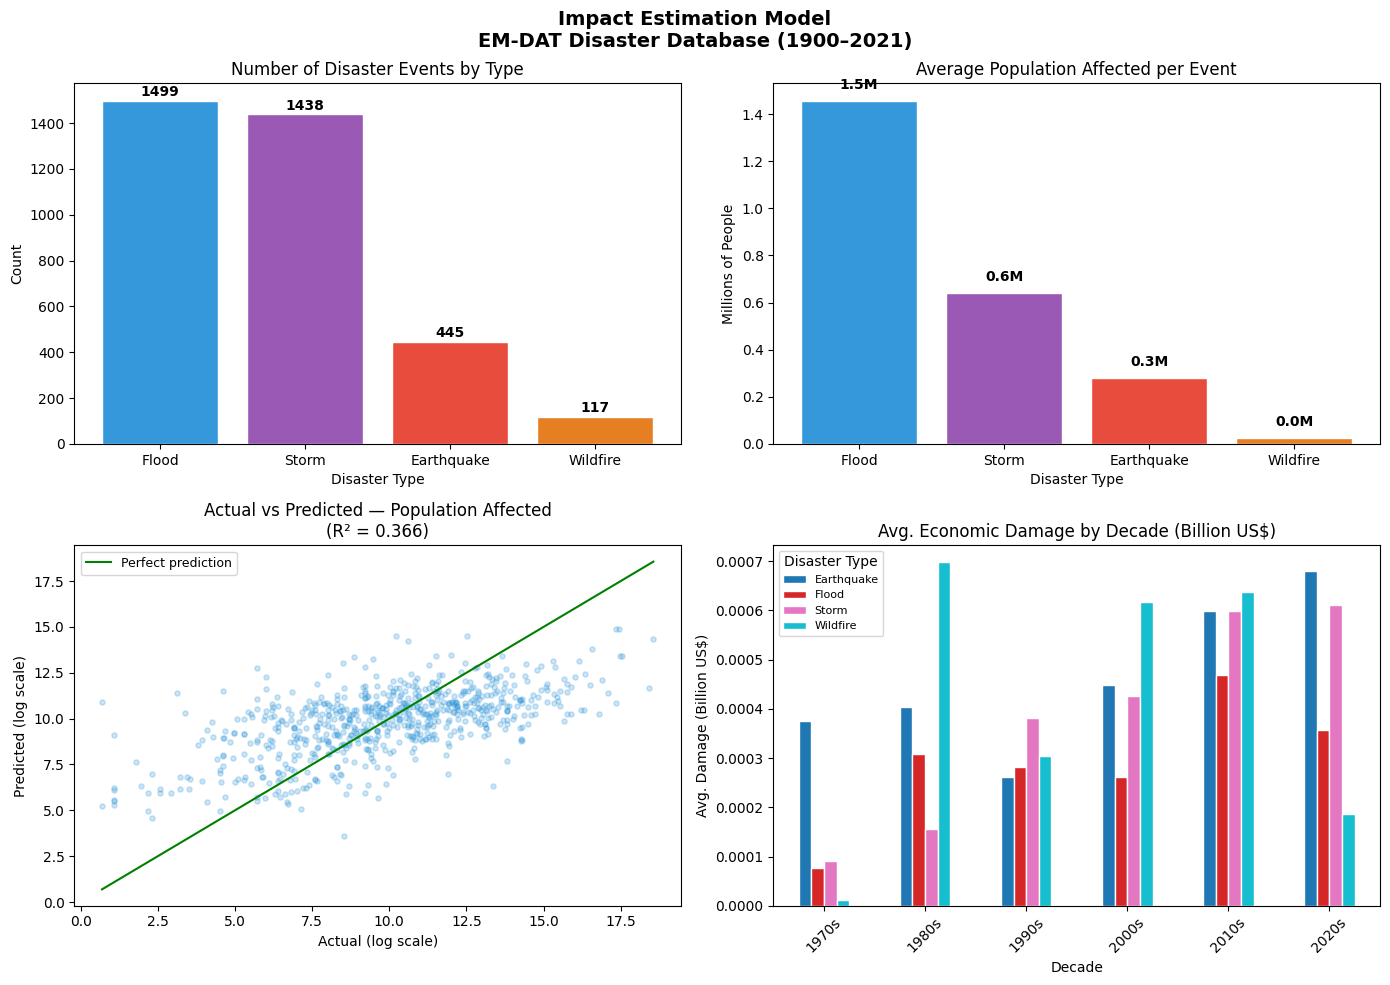

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Impact Estimation Model\n"
    "EM-DAT Disaster Database (1900–2021)",
    fontsize=14, fontweight="bold"
)

type_colors = ["#3498db", "#9b59b6", "#e74c3c", "#e67e22"]


type_counts = impact_df["Disaster Type"].value_counts()
bars = axes[0, 0].bar(type_counts.index, type_counts.values,
                      color=type_colors, edgecolor="white")
axes[0, 0].set_title("Number of Disaster Events by Type")
axes[0, 0].set_xlabel("Disaster Type")
axes[0, 0].set_ylabel("Count")
for bar, v in zip(bars, type_counts.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, v + 20,
                    str(v), ha="center", fontsize=10, fontweight="bold")


avg_pop = (impact_df.groupby("Disaster Type")["Total Affected"]
           .mean().sort_values(ascending=False))
bars2 = axes[0, 1].bar(avg_pop.index, avg_pop.values / 1e6,
                       color=type_colors[:len(avg_pop)], edgecolor="white")
axes[0, 1].set_title("Average Population Affected per Event")
axes[0, 1].set_xlabel("Disaster Type")
axes[0, 1].set_ylabel("Millions of People")
for bar, v in zip(bars2, avg_pop.values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, v/1e6 + 0.05,
                    f"{v/1e6:.1f}M", ha="center", fontsize=10, fontweight="bold")


axes[1, 0].scatter(yp_test, pop_pred_log, alpha=0.25, s=14, color="#3498db")
mn = min(yp_test.min(), pop_pred_log.min())
mx = max(yp_test.max(), pop_pred_log.max())
axes[1, 0].plot([mn, mx], [mn, mx],color="green", label="Perfect prediction")
axes[1, 0].set_title(f"Actual vs Predicted — Population Affected\n(R² = {r2_pop:.3f})")
axes[1, 0].set_xlabel("Actual (log scale)")
axes[1, 0].set_ylabel("Predicted (log scale)")
axes[1, 0].legend(fontsize=9)


impact_df["Decade"] = (impact_df["Start Year"] // 10 * 10).astype(str) + "s"
decade_damage = (
    impact_df.groupby(["Decade", "Disaster Type"])["Economic_Damage"]
    .mean().unstack(fill_value=0) / 1e9
)
decade_damage = decade_damage[decade_damage.index >= "1960s"]
decade_damage.plot(kind="bar", ax=axes[1, 1],
                   colormap="tab10", edgecolor="white", rot=45)
axes[1, 1].set_title("Avg. Economic Damage by Decade (Billion US$)")
axes[1, 1].set_xlabel("Decade")
axes[1, 1].set_ylabel("Avg. Damage (Billion US$)")
axes[1, 1].legend(fontsize=8, title="Disaster Type")

plt.tight_layout()


NameError: name 'null' is not defined